In [35]:
import pandas
import copy
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import seaborn as sbn
import sys
import matplotlib.pyplot as plt


# show all elements of a dataframe
# pandas.set_option("display.max_rows", None)
pandas.set_option("display.max_columns", None)


sys.path.append("../../src/")

In [36]:
from clustering_utility import compute_similarity_matrix

In [37]:
races = pd.read_csv('../../dataset/preprocessedRaces_without_outliers.csv', sep=",")
races.head()

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,date,climb/length,median_delta,std_delta
0,tour-de-france/1978/stage-6,Tour de France,100,NaN,162000,1101,1,1241,NaN,1,0,0,1978-07-05,0.006796,27.0,6.847590
1,vuelta-a-espana/2016/stage-14,Vuelta a España,80,100.0,196000,5575,5,821,NaN,1,0,0,2016-09-03,0.028444,1957.0,873.835670
2,tour-de-france/2019/stage-21,Tour de France,100,120.0,128000,781,1,1699,NaN,1,0,0,2019-07-28,0.006102,29.0,44.079531
3,volta-a-catalunya/1999/prologue,Volta Ciclista a Catalunya,50,NaN,8100,68,1,804,NaN,1,0,0,1999-06-17,0.008395,53.0,27.154498
4,tour-de-france/2022/stage-9,Tour de France,100,120.0,192900,3743,3,1551,24.0,1,0,0,2022-07-10,0.019404,1376.0,675.354230


In [38]:
races.isna().sum()

_url                      0
name                      0
points                    0
uci_points             3658
length                    0
climb_total               0
profile                   0
startlist_quality         0
average_temperature    5045
is_tarmac                 0
is_cobbled                0
is_gravel                 0
date                      0
climb/length              0
median_delta              0
std_delta                 0
dtype: int64

In [39]:
races.dtypes

_url                    object
name                    object
points                   int64
uci_points             float64
length                   int64
climb_total              int64
profile                  int64
startlist_quality        int64
average_temperature    float64
is_tarmac                int64
is_cobbled               int64
is_gravel                int64
date                    object
climb/length           float64
median_delta           float64
std_delta              float64
dtype: object

In [40]:
cyclists = pd.read_csv('../../dataset/preprocessedCyclists_without_outliers.csv', sep=",")
cyclists.head()

,name,BMI,median position,AVG position,# cyclist races,nationality,continent,geo area,birth_year,AVG weighted position,AVG position Autumn,AVG position Spring,AVG position Summer,AVG position Winter,AVG position Q1,AVG position Q2,AVG position Q3,AVG position Q4,std_dev position
0,gerrie-knetemann,19.959003,38,48,271,Netherlands,Europe,Western Europe,1951.0,66,56.0,15.0,58.0,NaN,15.0,18.0,66.0,NaN,46.993017
1,rene-bittinger,22.790000,42,47,146,France,Europe,Western Europe,1954.0,54,15.0,31.0,55.0,NaN,17.0,37.0,56.0,18.0,32.648452
2,joseph-bruyere,23.086015,8,16,48,Belgium,Europe,Western Europe,1948.0,21,29.0,11.0,19.0,NaN,5.0,14.0,23.0,NaN,19.723611
3,sven-ake-nilsson,21.300000,25,33,145,Sweden,Europe,Northern Europe,1951.0,38,17.0,12.0,38.0,NaN,14.0,27.0,37.0,16.0,26.276978
4,jacques-esclassan,20.916803,7,29,62,France,Europe,Western Europe,1948.0,43,6.0,7.0,36.0,NaN,4.0,27.0,39.0,NaN,34.928320


In [41]:
cyclists.shape

(5955, 19)

In [42]:
cyclists.isna().sum()

name                        0
BMI                         0
median position             0
AVG position                0
# cyclist races             0
nationality                 0
continent                   0
geo area                    0
birth_year                  0
AVG weighted position       0
AVG position Autumn      2861
AVG position Spring       732
AVG position Summer      1933
AVG position Winter      4449
AVG position Q1          1686
AVG position Q2          1014
AVG position Q3          2268
AVG position Q4          4243
std_dev position            0
dtype: int64

In [43]:
cyclists.dtypes

name                      object
BMI                      float64
median position            int64
AVG position               int64
# cyclist races            int64
nationality               object
continent                 object
geo area                  object
birth_year               float64
AVG weighted position      int64
AVG position Autumn      float64
AVG position Spring      float64
AVG position Summer      float64
AVG position Winter      float64
AVG position Q1          float64
AVG position Q2          float64
AVG position Q3          float64
AVG position Q4          float64
std_dev position         float64
dtype: object

# Clustering for cyclists

## Feature Selection

Feature selection based on NAN values and high correlation

In [44]:
numeric_columns = ['BMI', 'median position', 'std_dev position', '# cyclist races', 'birth_year']
numeric_cyclists_df = cyclists[numeric_columns]
numeric_cyclists_df

,BMI,median position,std_dev position,# cyclist races,birth_year
0,19.959003,38,46.993017,271,1951.0
1,22.790000,42,32.648452,146,1954.0
2,23.086015,8,19.723611,48,1948.0
3,21.300000,25,26.276978,145,1951.0
4,20.916803,7,34.928320,62,1948.0
...,...,...,...,...,...
5950,19.696783,173,0.000000,1,1969.0
5951,20.031931,17,0.000000,1,1965.0
5952,25.450000,54,0.000000,1,1992.0
5953,20.011635,38,0.000000,1,1948.0


,BMI,median position,std_dev position,# cyclist races,birth_year
BMI,1.000000,0.004362,0.048782,-0.015191,-0.133627
median position,0.004362,1.000000,0.272617,-0.045474,0.497785
std_dev position,0.048782,0.272617,1.000000,0.387355,0.250756
# cyclist races,-0.015191,-0.045474,0.387355,1.000000,0.158997
birth_year,-0.133627,0.497785,0.250756,0.158997,1.000000


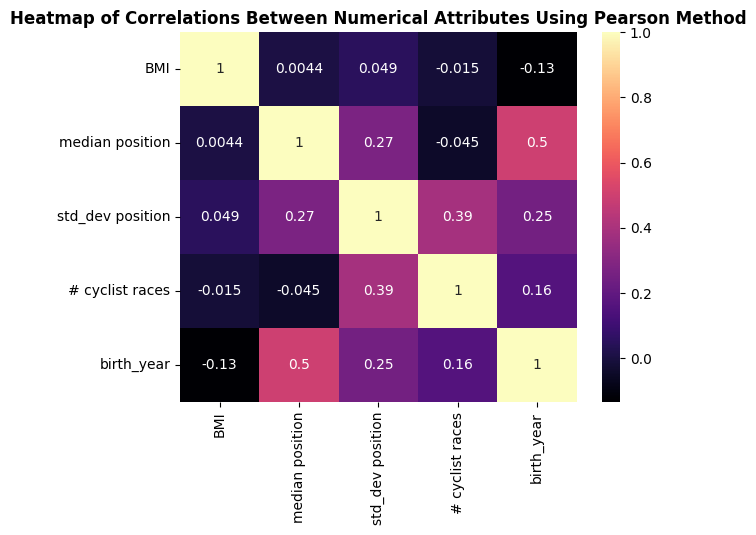

In [45]:
pearson_matrix = numeric_cyclists_df.corr(method='pearson')
display(pearson_matrix)
sbn.heatmap(pearson_matrix, annot=True, cmap="magma")
plt.title("Heatmap of Correlations Between Numerical Attributes Using Pearson Method", fontweight='bold')
plt.show()
plt.close()

## Data normalization

In [46]:
from sklearn.preprocessing import StandardScaler

def standardize_fun(df):
    scaler = StandardScaler()
    scaler.fit(df)
    X = scaler.transform(df)
    standardized_df = pd.DataFrame(X, columns=df.columns, index=df.index)
    print(standardized_df)
    
    standardizer = {"scaler": scaler, "standardized_df": standardized_df}

    return standardizer
   


In [47]:
standardizer = standardize_fun(numeric_cyclists_df)
standardized_cyclists_df = standardizer['standardized_df']

           BMI  median position  std_dev position  # cyclist races  birth_year
0    -0.933289        -1.016874          0.799777         1.563687   -1.462154
1     1.167189        -0.910558         -0.009832         0.507560   -1.270509
2     1.386820        -1.814251         -0.739312        -0.320444   -1.653798
3     0.061673        -1.362404         -0.369439         0.499111   -1.462154
4    -0.222643        -1.840830          0.118844        -0.202158   -1.653798
...        ...              ...               ...              ...         ...
5950 -1.127846         2.571318         -1.852516        -0.717548   -0.312285
5951 -0.879180        -1.575038         -1.852516        -0.717548   -0.567811
5952  3.140796        -0.591607         -1.852516        -0.717548    1.156992
5953 -0.894239        -1.016874         -1.852516        -0.717548   -1.653798
5954  1.493976        -0.405553         -1.852516        -0.717548   -1.398272

[5955 rows x 5 columns]


## PCA
We apply Principal Component Analysis (PCA) to the standardized dataset (standardized_cyclists_df) to reduce its dimensionality while preserving 90% of the variance. It calculates the number of principal components required to achieve this variance threshold and transforms the dataset into the PCA-reduced space

In [48]:
# Try to apply PCA to get the optimal number of components
pca_instance = PCA(n_components=0.90)  # Preserve 90% of the variance
pca_std_numeric_cyclists = pca_instance.fit_transform(standardized_cyclists_df)

print(f"# selected principal components: {pca_instance.n_components_}")

# selected principal components: 4


In [49]:
pca_std_numeric_cyclists

array([[-0.34956381,  2.03816271, -1.40192112,  0.73325803],
       [-1.11512137,  1.48753928,  0.75144621, -0.01285046],
       [-2.48880771,  1.23476398,  0.88103493, -0.1422566 ],
       ...,
       [-1.0773674 , -0.43653015,  2.66131075, -2.48289351],
       [-2.6380196 , -0.48055358, -0.95833783,  0.02827371],
       [-2.33549507, -0.16649217,  1.38075703, -0.66367382]])

## Kmeans grid search

In [50]:
def kmeans_grid_search(df):
    results = []  # used to save sse and silhouette for each k
    previous_sse = None

    for k in range(2,16):
        kmeans = KMeans(n_clusters=k, max_iter=300, random_state=42)
        labels = kmeans.fit_predict(df)
        sse = kmeans.inertia_  # Calcola il SSE
        silhouette_avg = silhouette_score(df, labels) 

        if previous_sse is not None:
            sse_reduction_percentage = ((previous_sse - sse) / previous_sse) * 100
            print(f"k: {k} -> silhouette: {silhouette_avg}, sse: {sse}, sse reduction: {sse_reduction_percentage:.2f}%")
        else:
            print(f"k: {k} -> silhouette: {silhouette_avg}, sse: {sse}")
    
        # Salva i risultati
        results.append({"k": k, "sse": sse, "silhouette": silhouette_avg})
        previous_sse = sse
   
    return results

In [51]:
def k_means_evaluation_plotting(results):

    print(results)
    k_values = [result["k"] for result in results]
    sse_values = [result["sse"] for result in results]
    silhouette_values = [result["silhouette"] for result in results]

    plt.figure()
    plt.plot(k_values, sse_values, marker='o', label='SSE')
    plt.title('SSE with Elbow method')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('SSE')
    plt.show()

    plt.figure()
    plt.plot(k_values, silhouette_values, marker='o', label='Silhouette Score', color='orange')
    plt.title('Silhouette Score')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.show()

In [52]:
def get_best_k(results):
    best_result = max(results, key=lambda x: x["silhouette"])

    best_k = best_result["k"]
    return best_k

In [53]:
results = kmeans_grid_search(pca_std_numeric_cyclists)

k: 2 -> silhouette: 0.2837349106368867, sse: 19671.28164379123
k: 3 -> silhouette: 0.28171711397061683, sse: 15412.846817790334, sse reduction: 21.65%
k: 4 -> silhouette: 0.257503897513941, sse: 12985.707608973273, sse reduction: 15.75%
k: 5 -> silhouette: 0.24975695940082465, sse: 11481.25152469725, sse reduction: 11.59%
k: 6 -> silhouette: 0.24520918814214157, sse: 10178.10516153656, sse reduction: 11.35%
k: 7 -> silhouette: 0.23283130213025155, sse: 9639.235368571884, sse reduction: 5.29%
k: 8 -> silhouette: 0.22940309632612155, sse: 8721.967865673698, sse reduction: 9.52%
k: 9 -> silhouette: 0.21986717947218792, sse: 8259.748418000701, sse reduction: 5.30%
k: 10 -> silhouette: 0.21213322568669402, sse: 7813.744566831494, sse reduction: 5.40%
k: 11 -> silhouette: 0.2087463014370653, sse: 7427.345731018798, sse reduction: 4.95%
k: 12 -> silhouette: 0.20887244021381515, sse: 7086.457280355037, sse reduction: 4.59%
k: 13 -> silhouette: 0.19875614609643127, sse: 6898.823525563203, sse r

[{'k': 2, 'sse': 19671.28164379123, 'silhouette': np.float64(0.2837349106368867)}, {'k': 3, 'sse': 15412.846817790334, 'silhouette': np.float64(0.28171711397061683)}, {'k': 4, 'sse': 12985.707608973273, 'silhouette': np.float64(0.257503897513941)}, {'k': 5, 'sse': 11481.25152469725, 'silhouette': np.float64(0.24975695940082465)}, {'k': 6, 'sse': 10178.10516153656, 'silhouette': np.float64(0.24520918814214157)}, {'k': 7, 'sse': 9639.235368571884, 'silhouette': np.float64(0.23283130213025155)}, {'k': 8, 'sse': 8721.967865673698, 'silhouette': np.float64(0.22940309632612155)}, {'k': 9, 'sse': 8259.748418000701, 'silhouette': np.float64(0.21986717947218792)}, {'k': 10, 'sse': 7813.744566831494, 'silhouette': np.float64(0.21213322568669402)}, {'k': 11, 'sse': 7427.345731018798, 'silhouette': np.float64(0.2087463014370653)}, {'k': 12, 'sse': 7086.457280355037, 'silhouette': np.float64(0.20887244021381515)}, {'k': 13, 'sse': 6898.823525563203, 'silhouette': np.float64(0.19875614609643127)}, {

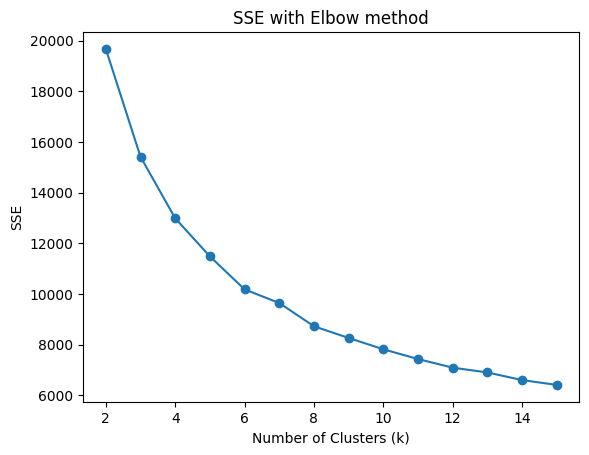

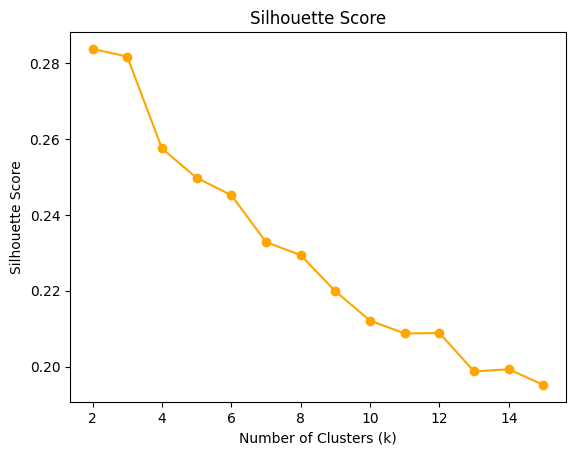

In [54]:
k_means_evaluation_plotting(results)

## Compute Kmeans algorithm with best K found
Analyzing the Elbow Method of SSE and the Silhouette Score, the optimal  k  values do not align. The Silhouette Score suggests  k = 2  as the optimal number of clusters, while the SSE indicates  k = 5  or  k = 6 . As a trade-off, we choose  k = 4 .

In [55]:
def kmeans_run(data, best_k, scaler):
    scaler = standardizer['scaler']
    print(f"\nBest k: {best_k}")
    
    # best kmeans with best clusters number
    best_kmeans = KMeans(n_clusters=best_k, random_state=42, init='k-means++', max_iter=300)

    best_kmeans.fit(data)
    print(f"k: {best_k}, Number of iterations: {best_kmeans.n_iter_}")

    centers = best_kmeans.cluster_centers_

    # Trasforma i centroidi dallo spazio PCA a quello standardizzato
    centers_standardized = pca_instance.inverse_transform(centers)

    # Inverso della trasformazione per ottenere i centroidi nello spazio originale (non normalizzato)
    centers_original_space = scaler.inverse_transform(centers_standardized)

    print("Centroids")
    print(centers_original_space)

    kmeans_data = {"best_kmeans": best_kmeans, "centroids": centers_original_space}

    return kmeans_data

  



In [56]:
kmeans_data = kmeans_run(data=pca_std_numeric_cyclists, best_k=4, scaler=standardizer['scaler'])
best_kmeans = kmeans_data['best_kmeans']
centroids = kmeans_data['centroids']


Best k: 4
k: 4, Number of iterations: 11
Centroids
[[  20.94884911   59.91241468   44.32571579  294.29959499 1981.22013319]
 [  20.54260068  102.91353931   28.66011261   38.93422771 1986.01942209]
 [  22.05016545   91.47887253   46.24838042   74.81567317 1971.28352836]
 [  21.31245481   35.01335444   14.7625842    17.16481658 1956.05627055]]


In [57]:
# count points for each cluster
cluster_counts = pd.Series(best_kmeans.labels_).value_counts().sort_index()

print("Number of points for each cluster")
print(cluster_counts)

Number of points for each cluster
0     984
1    1873
2    1664
3    1434
Name: count, dtype: int64


Let's print a summary of the average values for each feature within the clusters

In [58]:
numeric_cyclists_df = numeric_cyclists_df.copy() 
# Add Cluster as a column to the dataset
numeric_cyclists_df['Cluster'] = best_kmeans.labels_

# Compute statistics for each feature grouped by cluster
detailed_cluster_stats = numeric_cyclists_df.groupby('Cluster').agg(['mean', 'median', 'min', 'max'])

detailed_cluster_stats.columns = ['_'.join(col) for col in detailed_cluster_stats.columns]

display(detailed_cluster_stats)

,BMI_mean,BMI_median,BMI_min,BMI_max,median position_mean,median position_median,median position_min,median position_max,std_dev position_mean,std_dev position_median,std_dev position_min,std_dev position_max,# cyclist races_mean,# cyclist races_median,# cyclist races_min,# cyclist races_max,birth_year_mean,birth_year_median,birth_year_min,birth_year_max
Cluster,,,,,,,,,,,,,,,,,,,,
0,20.915235,20.900000,17.412666,25.310000,66.799797,67.0,8,131,42.622679,42.148645,18.713423,72.428232,308.294715,295.0,92,549,1978.840447,1979.0,1946.0,2000.0
1,20.548025,20.570000,17.263427,24.432154,101.155366,101.0,9,184,29.157312,33.270150,0.000000,65.760931,35.456487,17.0,1,220,1986.616658,1988.0,1951.0,2004.0
2,22.069447,22.040000,18.833727,26.750000,89.225962,90.0,4,178,46.725342,45.960965,0.000000,97.274526,70.152043,49.0,1,358,1972.079327,1971.0,1940.0,2002.0
3,21.308165,21.283847,17.486589,26.530000,35.182008,31.0,0,143,14.752854,13.034675,0.000000,58.149592,17.565551,4.0,1,267,1955.965132,1955.0,1933.0,1992.0


## Distribution of points for each feature across clusters

In [59]:
def clusters_box_plot(df):

    columns = [col for col in df.columns if col != 'Cluster']
    n_rows = (len(columns) + 2 - 1) // 2  

    fig, axes = plt.subplots(n_rows, 2, figsize=(14, 5 * n_rows), sharey=False)

    # Rendi axes un array 1D per un accesso più semplice
    axes = axes.flatten()

    for i, column in enumerate(columns):
        sbn.boxplot(x='Cluster', y=column, data=df, ax=axes[i])
        axes[i].set_title(f"Distribution of '{column}'")
        axes[i].set_xlabel("Cluster")
        axes[i].set_ylabel(column)

    # Nascondi subplot extra (se presenti)
    for j in range(len(columns), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

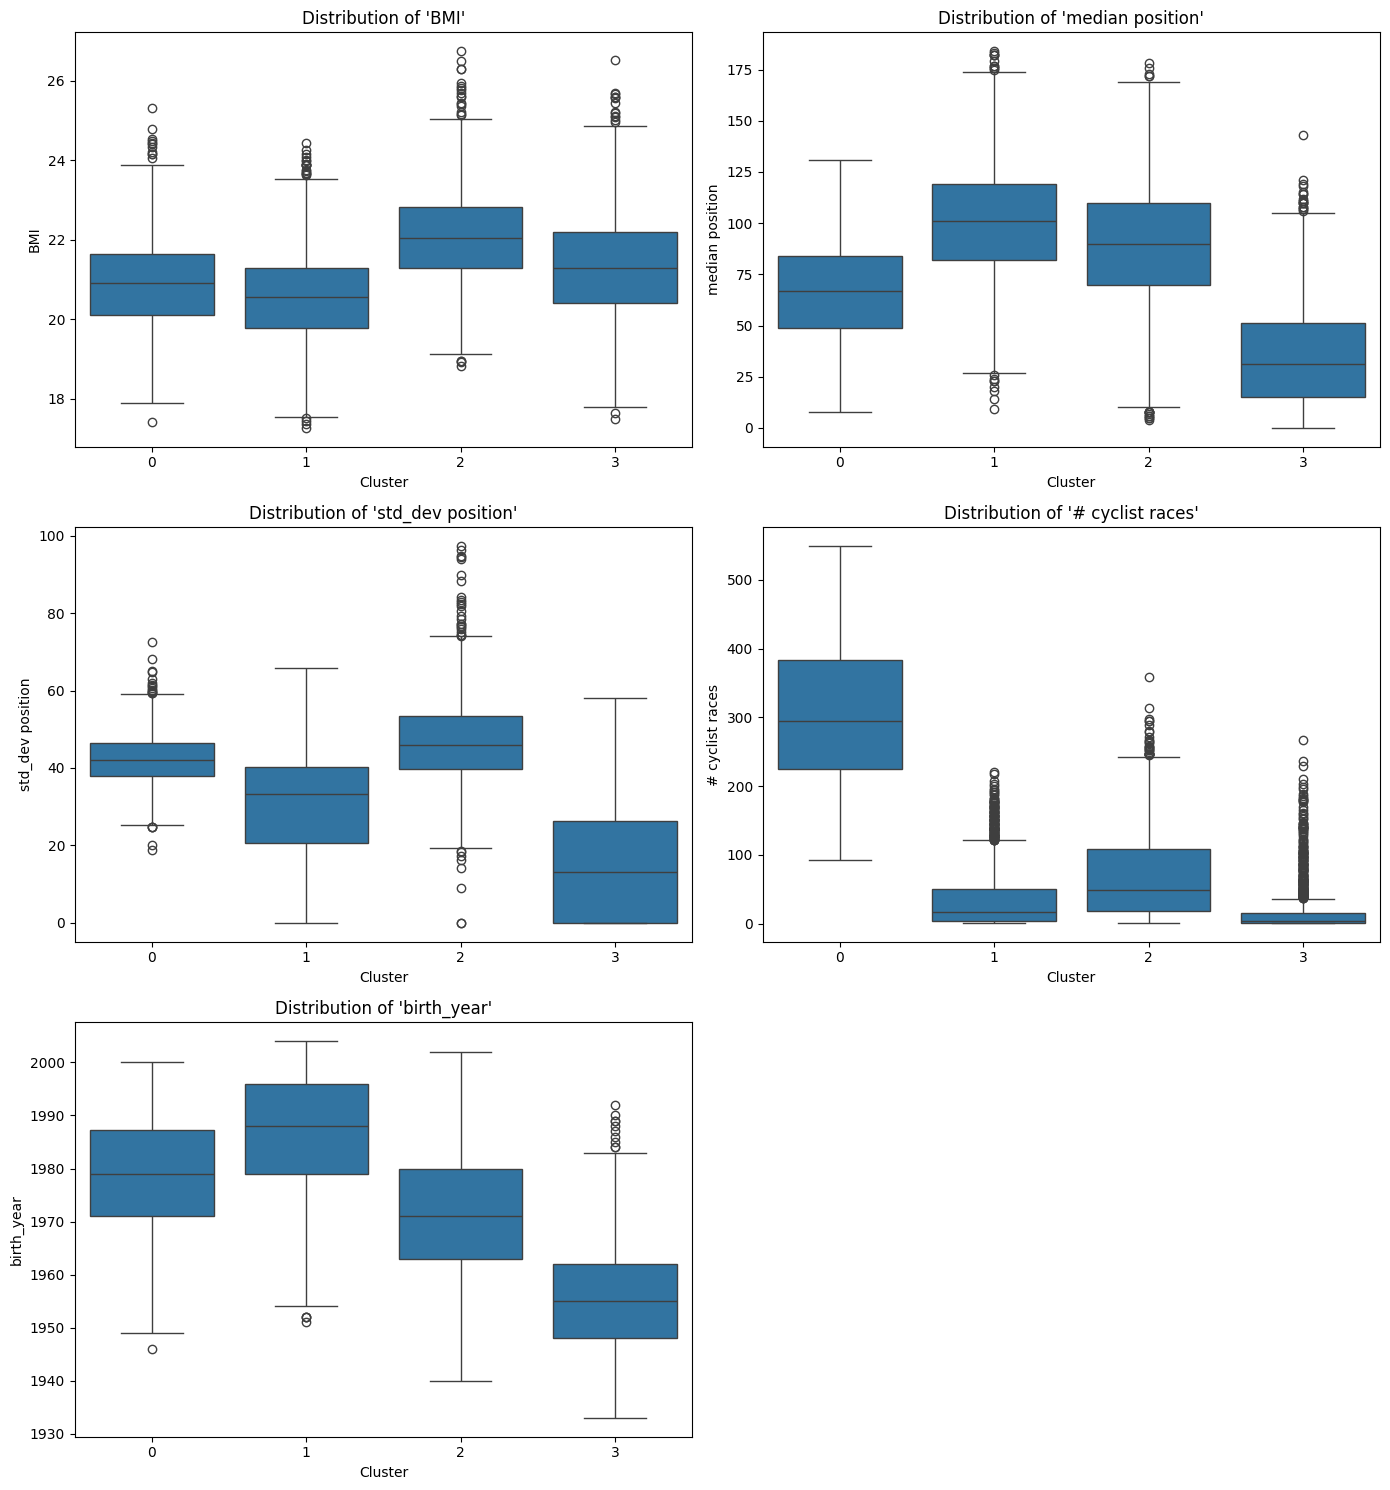

In [60]:
clusters_box_plot(numeric_cyclists_df)

### Box-plots analysis

By analying the box-plots above, we can try to analyze the 4 clusters by considering points distribution for each feature:
- **Cluster 0** (984 points): 

  - **_BMI_**: values are centered around a median of 21, with a moderately tight interquartile range. There are some outliers on both the lower and upper ends, with the lowest BMI slightly above 18 and the highest below 26.
  
  - **_median position_**: this cluster has a wide enough IQR for the median position, but the narrowest among all other clusters, with values ranging from ~50 to ~90. The median is approximately 70. There are no outliers.

  - **_# cyclist races_**: cyclists in this cluster participated in the largest number of races with a median of 300. IQR is the widest and spreads from ~220 to ~380. There are no outliers.
  
  - **_birth\_year_**: this cluster has a median birth year around 1980, with an IQR ranging from ~1971 to ~ 1988. There are one or a few outliers below 1950.

  - **_std\_dev position_**: the median standard deviation of position is around 42 and IQR is the narrowest. This cluster has a lot of outliers on both the lower and the upper ends, below 20 and beyond 65.

- **Cluster 1** (1873 points): 

  - **_BMI_**: the median BMI is approximately 21, and outliers are present on both ends. The IQR depth is quite similar to that of Cluster 0, but with slighlty lower values.
  
  - **_median position_**: the median position is the highest compared to the other clusters. The median values is around 100 and there are many high-end outliers over 175, and many low-end outliers close to 5.

  - **_# cyclist races_**: the distribution shows a tighter IQR and a lower median, around 15. There are many high-end outliers, with values over 200.
  
  - **_birth\_year_**: the median birth year is ~1990, the highest compared to the other clusters. Outliers are present just above the ~1950s.

  - **_std\_dev position_**: the median std deviation of position is around 30 and the IQR ranges from ~20 to ~40. There are not outliers.

- **Cluster 2** (1664 points): 

  - **_BMI_**: the median BMI is around 22, the highest. There are many outliers up to over 26, and some around 19.
  
  - **_median position_**: this cluster has the widest IQR compared to the others, with a median position around ~90. There are some high-end and low-end outliers.

  - **_# cyclist races_**: the median of number of races in this cluster is about 50 and also contains a significant number of high-end outliers, the highest just below 400.
  
  - **_birth\_year_**: IQR here, ranges from ~1965 to ~1980 and the median value is approximately 1971. There are no outliers.

  - **_std\_dev position_**: this cluster has the highest median standard deviation of position, around 45. The are a lot of high-end outliers up to 100, and a lot of low-end outliers down to 0.

- **Cluster 3** (1434 points): 

  - **_BMI_**: median is about ~21 and the IQR is the slightly widest. There are few low-end outliers and many other high-end ones.
  
  - **_median position_**: the median position is the smallest here, about ~30, with some outliers on the upper end up to ~150.

  - **_# cyclist races_**: cyclists in this cluster have the smallest number of races, with a median around 15 and the tightest IQR. There are a lot of outliers on the upper part, up to about ~300
  
  - **_birth\_year_**: this cluster has the cyclists born in more distant years, with a median around 1955. Some outliers extend to earlier years, up to 1990s.

  - **_std\_dev position_**: this cluster has the smallest median standard deviation of position, ~15, but the widest IQR, ranging from ~0 to ~30, suggesting more consistency in performance. There are no outliers.




 

Based on the analysis provided, here’s what we can infer about the clusters:
#### Cluster 0
Cluster 0 could represent highly experienced cyclists with a median of ~300 races, the highest among all clusters. Their performance, however, is inconsistent, as indicated by a high median standard deviation of positions (~42) and many outliers. These cyclists, born around 1980.

#### Cluster 1
Cluster 1 consists of cyclists with a median birth year of ~1990 and limited race participation (~15 races). They reached the worst median positions (~100) but, despite this, their standard deviation of positions (~45) shows relatively consistent but average performance, characteristic of those still developing in the sport.

#### Cluster 2
Cluster 2 is characterized by cyclists born in the 70s, with moderate race experience (~50 races). Their performance varies significantly, as seen in the wide IQR for race positions and the highest median standard deviation (~45). This group seems to balance competitiveness with fluctuating results.

#### Cluster 3
Cluster 3 is composed of the cyclists born in more distant years, as reflected by their distant median birth year (~1955). Despite participating in fewer races overall, they achieve strong and consistent performance, with the best median race positions (~30) and the smallest variability in results. This group likely includes highly selective participants who compete less frequently but perform at a high level. 

But we must highlight that these results could only be distorted by the fact that they participated in very few competitions.

## Clusters visualization with feature distributions and centroids 

In [61]:
    
def clusters_pairplot(df, centroids):
    pairplot = sbn.pairplot(
        df,
        hue='Cluster',
        palette='Set1',
        diag_kind='kde',
        markers='o',
        plot_kws={'alpha': 0.5}
    )

    for i, ax in enumerate(pairplot.axes.flat):
        # Get features for each subplot
        row_feature = pairplot.axes.flat[i].get_ylabel()
        col_feature = pairplot.axes.flat[i].get_xlabel()

        # Add centroids only to relevant scatter plots, excluding diagonal ones
        if row_feature in df.columns and col_feature in df.columns:
            ax.scatter(
                centroids[:, df.columns.get_loc(col_feature)],  
                centroids[:, df.columns.get_loc(row_feature)], 
                marker='x', s=100, c='black', label='Centroid'
            )

    plt.legend()
    plt.show()

/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_3496/1658901490.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


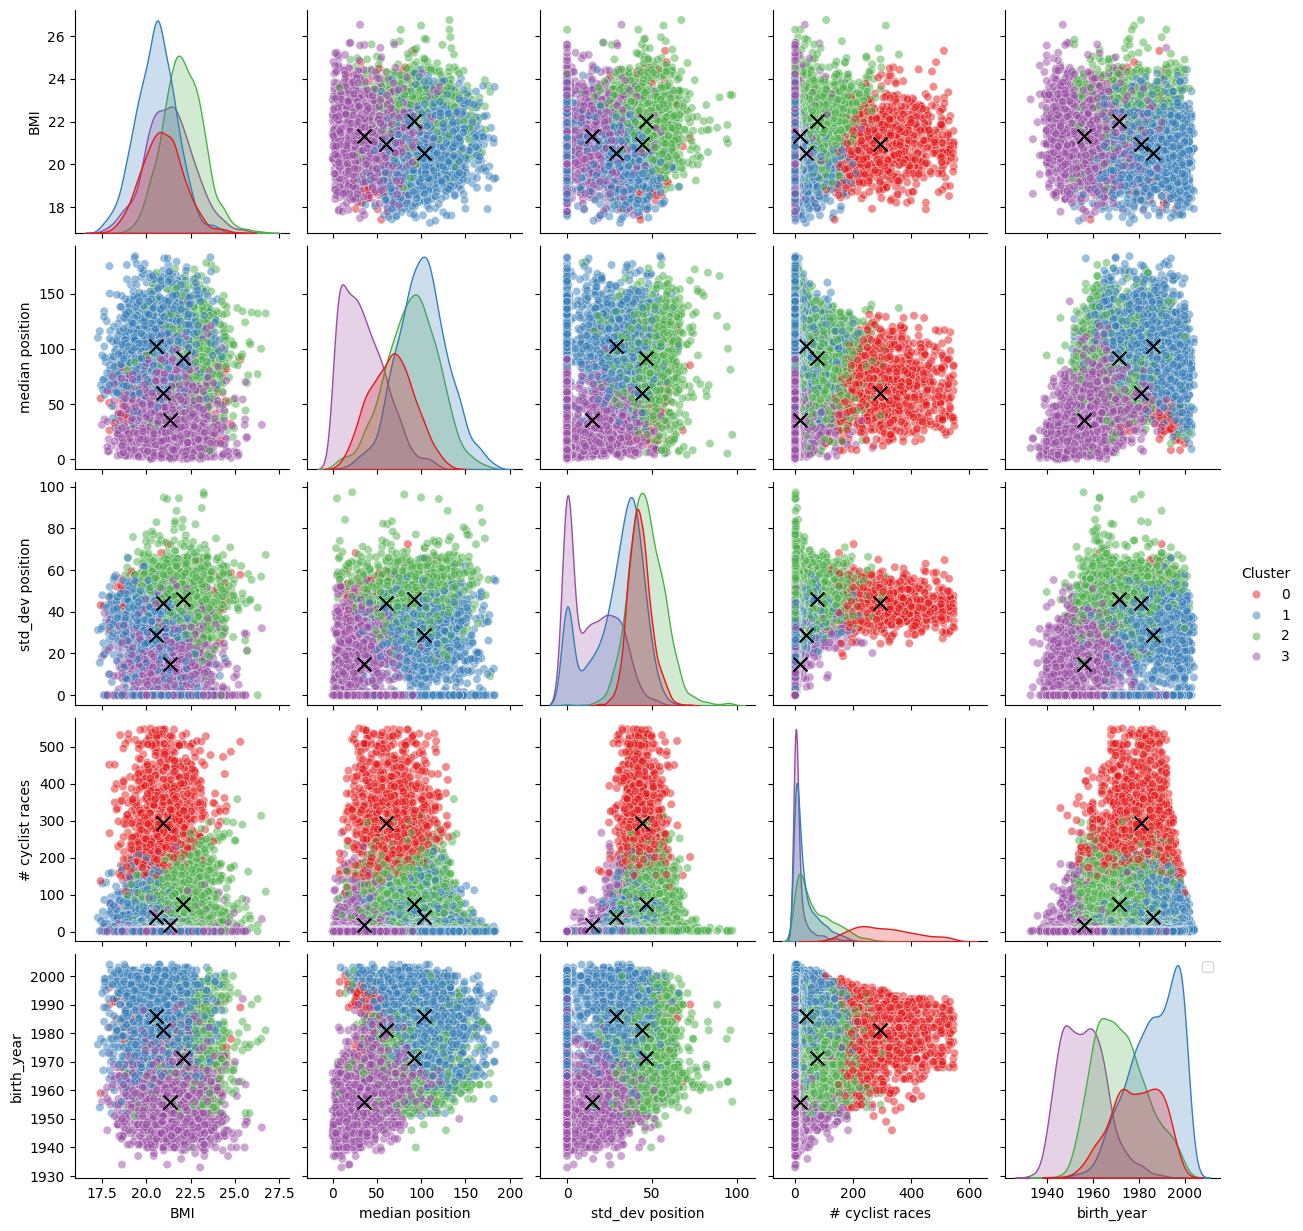

In [62]:
clusters_pairplot(numeric_cyclists_df, centroids)

### Pairplot analysis

By analyzing the paiplot above, we can try to analyze the 4 clusters and try to catch any relationships and patterns between the characteristics of the clusters that we were unable to catch with the box plots
- **Cluster 0**: 

  - **_std\_dev position_** vs **_# cyclist races**: cyclists with a high number of races tend to have higher standard deviations in their race positions, reflecting more variability in their performance. But this is also quite normal.
  
  - **_# cyclist races_** vs **_birth\_year_**: it seems that cyclists born in more recent years, tend to participate to more races.

- **Cluster 1**: 

  - **_birth\_year_** vs **_median position_**: it seems like that there is a light relationship. Cyclists with worse rankings (higher median positions) tend to be born in earlier years and viceversa.

  - **_median position_** vs **_BMI_**: there is a weak relationship: cyclists with better performance (low median position) have lower BMI values.

  - **_std\_dev position_** vs **_median position_**: cyclists with higher standard deviations in race positions tend to have better median position.
  
- **Cluster 2**: 

  -  **_BMI_** vs **_# cyclist races_**: it appears that cyclists with higher BMI have participated to more races.

  -  **_BMI_** vs **_std\_dev position_**: cyclists with higher BMI seems to have more consistent performances (lower std_dev position).
  
  -  **# cyclist races** vs **_std\_dev position_**: there is a slight relation: higher values of standard deviation of position correspond to lower number of cyclist races.
  
- **Cluster 3**: 
  
  - **_# cyclist races_** vs **_birth\_year_**: in this cluster, cyclists born in more recent years, tend do partecipate to more races, as in Cluster 0.
  
  - **_birth\_year_** vs **_median position_**: it seems that cyclist born after 1960s, have got worse median position (higher values)
  
  - **_std\_dev position_** vs **_# cyclist races**: as in Cluster 0, cyclists with a high number of races appear to have higher standard deviations in their race positions, reflecting more variability in their performance.
 



 

### Parallel coordinates plot

In [63]:
columns = numeric_cyclists_df.drop('Cluster',axis=1).columns

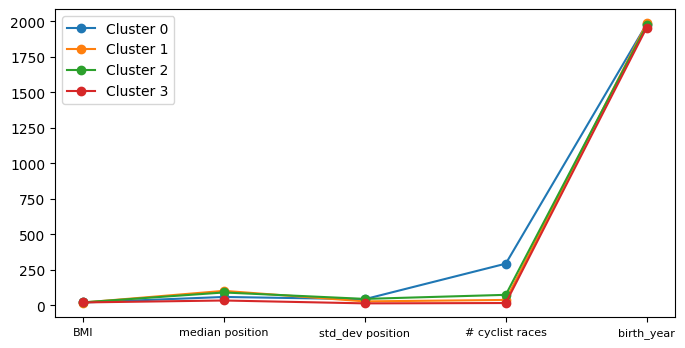

In [64]:
plt.figure(figsize=(8, 4))
for i in range(0, len(centroids)):
    plt.plot(centroids[i], marker='o', label='Cluster %s' % i)
plt.tick_params(axis='both', which='major', labelsize=10)
plt.xticks(range(0, len(columns)), columns, fontsize=8)
plt.legend(fontsize=10)
plt.show()

Plotting with centroids normalized

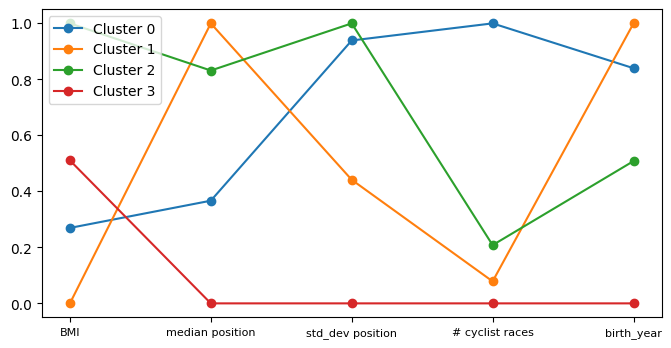

In [65]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
centroids_normalized = scaler.fit_transform(centroids)

plt.figure(figsize=(8, 4))
for i in range(0, len(centroids_normalized)):
    plt.plot(centroids_normalized[i], marker='o', label='Cluster %s' % i)

plt.tick_params(axis='both', which='major', labelsize=10)
plt.xticks(range(0, len(columns)), columns, fontsize=8)
plt.legend(fontsize=10)
plt.show()

### Spider plot


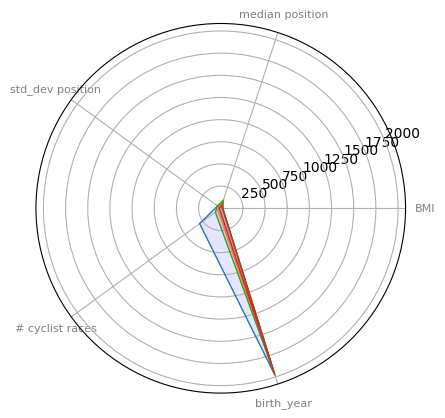

In [66]:
from math import pi
 
# number of variable
N = len(columns)
# What will be the angle of each axis in the plot? (we divide the plot / number of variable)
for i in range(0, len(centroids)):
    angles = [n / float(N) * 2 * pi for n in range(N)]
    values = centroids[i].tolist()
    values += values[:1]
    angles += angles[:1]
# Initialise the spider plot
    ax = plt.subplot(polar=True)
# Draw one axe per variable + add labels labels yet
    plt.xticks(angles[:-1], columns, color='grey', size=8) 
# Plot data
    ax.plot(angles, values, linewidth=1, linestyle='solid')
 # Fill area
    ax.fill(angles, values, 'b', alpha=0.1)

Spider plot with centroids normalized

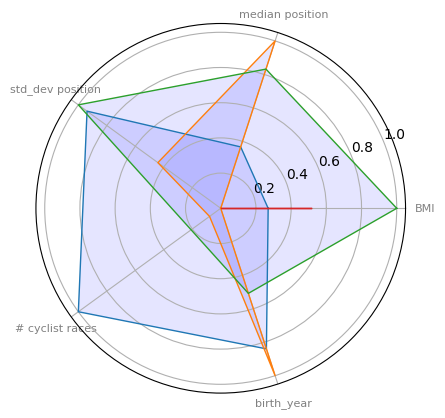

In [67]:
# number of variable
N = len(columns)
# What will be the angle of each axis in the plot? (we divide the plot / number of variable)
for i in range(0, len(centroids_normalized)):
    angles = [n / float(N) * 2 * pi for n in range(N)]
    values = centroids_normalized[i].tolist()
    values += values[:1]
    angles += angles[:1]
# Initialise the spider plot
    ax = plt.subplot(polar=True)
# Draw one axe per variable + add labels labels yet
    plt.xticks(angles[:-1], columns, color='grey', size=8) 
# Plot data
    ax.plot(angles, values, linewidth=1, linestyle='solid')
 # Fill area
    ax.fill(angles, values, 'b', alpha=0.1)

## Similarity matrix for Clusters Validation

In the following, we use the similarity matrix for cluster validation, which allows us to evaluate how well-defined the clusters are by visualizing intra-cluster similarity (points within the same cluster should have high similarity) and inter-cluster dissimilarity (points from different clusters should have low similarity). This helps assess the quality of the clustering results and ensures that the clusters are distinct and meaningful.

In [68]:
num_components = pca_std_numeric_cyclists.shape[1]
column_names = [f'PC{i+1}' for i in range(num_components)]

# Convert pca ndarray into a dataframe
pca_df_cyclists = pd.DataFrame(pca_std_numeric_cyclists, columns=column_names)

print(pca_df_cyclists.head())

        PC1       PC2       PC3       PC4
0 -0.349564  2.038163 -1.401921  0.733258
1 -1.115121  1.487539  0.751446 -0.012850
2 -2.488808  1.234764  0.881035 -0.142257
3 -1.577047  1.293622 -0.402402  0.084075
4 -1.901658  1.213915 -0.557025  0.814083


Pearson correlation between the proximity matrix and the ideal similarity matrix: 0.4844


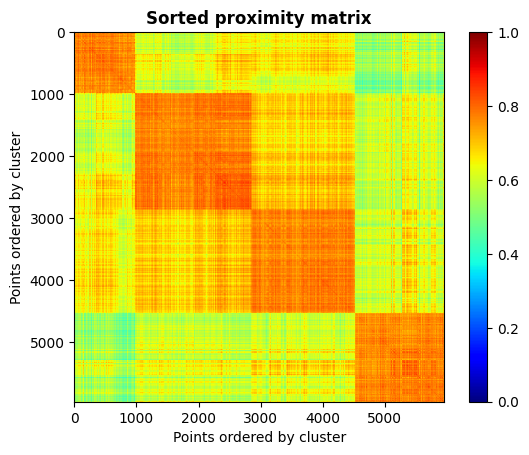

In [69]:
compute_similarity_matrix(pca_df_cyclists, best_kmeans.labels_)

In [70]:
for i in numeric_cyclists_df['Cluster'].unique():
    if i != -1:
        # std_dev for each numeric column
        std_values = numeric_cyclists_df[numeric_cyclists_df['Cluster'] == i].std(numeric_only=True)
        mean_std = std_values.mean()
        print(f"Cluster {i}: Average standard deviation = {mean_std}")

Cluster 0: Average standard deviation = 24.80550350357718
Cluster 3: Average standard deviation = 13.953611790221986
Cluster 2: Average standard deviation = 19.54560860528855
Cluster 1: Average standard deviation = 16.40560037418364


## Geographic distribution of cyclists across clusters
Here we analyzed the geographic distribution of cyclists across clusters by grouping them based on their geographic area and visualized the results. A bar chart was used to compare the counts of cyclists from different regions within each cluster. The chart highlights the relationships between geographic regions and cluster assignments, providing insights into how cyclists from various areas are distributed across the clusters.

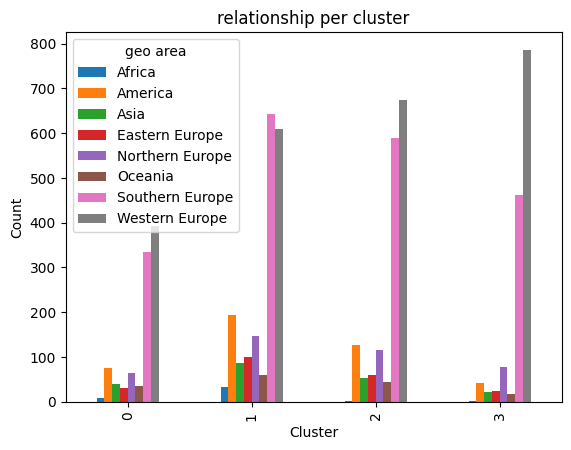

In [71]:
cross_df = pandas.crosstab(best_kmeans.labels_, cyclists['geo area'])

cross_df.plot(kind='bar', stacked=False, 
                   title='relationship per cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()

# Clustering for races

## Feature Selection

In [72]:
races.isna().sum()

_url                      0
name                      0
points                    0
uci_points             3658
length                    0
climb_total               0
profile                   0
startlist_quality         0
average_temperature    5045
is_tarmac                 0
is_cobbled                0
is_gravel                 0
date                      0
climb/length              0
median_delta              0
std_delta                 0
dtype: int64

In [73]:
races = races.dropna(axis=1, how='any')
races.isna().sum()

_url                 0
name                 0
points               0
length               0
climb_total          0
profile              0
startlist_quality    0
is_tarmac            0
is_cobbled           0
is_gravel            0
date                 0
climb/length         0
median_delta         0
std_delta            0
dtype: int64

In [74]:
numeric_races_df = races[['points', 'climb/length', 'median_delta', 'std_delta', 'startlist_quality', 'climb_total', 'length']]
numeric_races_df

,points,climb/length,median_delta,std_delta,startlist_quality,climb_total,length
0,100,0.006796,27.0,6.847590,1241,1101,162000
1,80,0.028444,1957.0,873.835670,821,5575,196000
2,100,0.006102,29.0,44.079531,1699,781,128000
3,50,0.008395,53.0,27.154498,804,68,8100
4,100,0.019404,1376.0,675.354230,1551,3743,192900
...,...,...,...,...,...,...,...
5245,80,0.009736,77.0,120.702086,881,1441,148000
5246,275,0.009700,270.0,327.665558,808,2648,273000
5247,50,0.009330,0.0,0.000000,779,1726,185000
5248,50,0.013783,209.0,176.293335,1045,1880,136400


Check pearson correlation between these non-nan numeric features

,points,climb/length,median_delta,std_delta,startlist_quality,climb_total,length
points,1.000000,-0.062609,0.056112,0.071796,0.148997,0.221306,0.444346
climb/length,-0.062609,1.000000,0.519310,0.311995,0.049439,0.597255,-0.118099
median_delta,0.056112,0.519310,1.000000,0.526316,0.209138,0.591644,0.134675
std_delta,0.071796,0.311995,0.526316,1.000000,0.105963,0.416863,0.167550
startlist_quality,0.148997,0.049439,0.209138,0.105963,1.000000,0.091359,0.067953
climb_total,0.221306,0.597255,0.591644,0.416863,0.091359,1.000000,0.590421
length,0.444346,-0.118099,0.134675,0.167550,0.067953,0.590421,1.000000


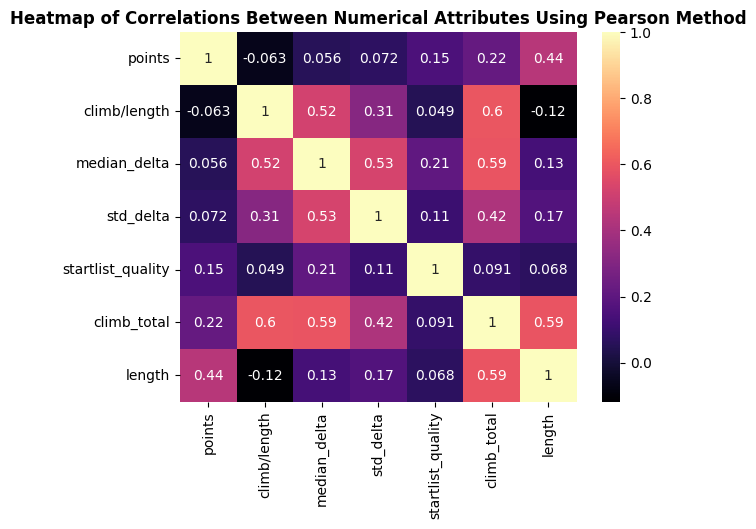

In [75]:
pearson_matrix = numeric_races_df.corr(method='pearson')
display(pearson_matrix)
sbn.heatmap(pearson_matrix, annot=True, cmap="magma")
plt.title("Heatmap of Correlations Between Numerical Attributes Using Pearson Method", fontweight='bold')
plt.show()
plt.close()

Since _std\_delta_ and _median\_delta_ are moderately correlated, we decide to drop _std\_delta_. Also _climb\_total_ is moderately correlated with a lot of features: _climb/length_, _length_ and _median\_delta_.
Given that, we chose to drop _climb\_total_  while retaining the others.

In [76]:
numeric_races_df = numeric_races_df.drop(['std_delta', 'climb_total'], axis=1)
numeric_races_df

,points,climb/length,median_delta,startlist_quality,length
0,100,0.006796,27.0,1241,162000
1,80,0.028444,1957.0,821,196000
2,100,0.006102,29.0,1699,128000
3,50,0.008395,53.0,804,8100
4,100,0.019404,1376.0,1551,192900
...,...,...,...,...,...
5245,80,0.009736,77.0,881,148000
5246,275,0.009700,270.0,808,273000
5247,50,0.009330,0.0,779,185000
5248,50,0.013783,209.0,1045,136400


## Data Normalization

In [77]:
standardizer = standardize_fun(numeric_races_df)
standardized_races_df = standardizer['standardized_df']

        points  climb/length  median_delta  startlist_quality    length
0     0.170544     -0.945837     -0.650569           0.662833 -0.062651
1    -0.154928      2.018417      3.498185          -0.443619  0.443333
2     0.170544     -1.040969     -0.646270           1.869394 -0.568635
3    -0.643137     -0.726915     -0.594679          -0.488404 -2.352972
4     0.170544      0.780543      2.249260           1.479501  0.397199
...        ...           ...           ...                ...       ...
5245 -0.154928     -0.543230     -0.543088          -0.285555 -0.270998
5246  3.018428     -0.548277     -0.128213          -0.477867  1.589237
5247 -0.643137     -0.598928     -0.708608          -0.554265  0.279632
5248 -0.643137      0.010867     -0.259339           0.146489 -0.443627
5249 -0.154928     -0.898382     -0.616175          -0.293458 -2.348508

[5250 rows x 5 columns]


## PCA
We apply Principal Component Analysis (PCA) to the standardized dataset (standardized_races_df) to reduce its dimensionality while preserving 90% of the variance. It calculates the number of principal components required to achieve this variance threshold and transforms the dataset into the PCA-reduced spac

In [78]:
pca_instance = PCA(n_components=0.90)  # Preserve 90% of the variance
pca_std_numeric_races = pca_instance.fit_transform(standardized_races_df)

print(f"# selected principal components: {pca_instance.n_components_}")

# selected principal components: 4


## Kmeans grid search

In [79]:
results = kmeans_grid_search(pca_std_numeric_races)

k: 2 -> silhouette: 0.3174893147360129, sse: 18316.652495743194
k: 3 -> silhouette: 0.36570111709221237, sse: 13585.018335357445, sse reduction: 25.83%
k: 4 -> silhouette: 0.36278256039908374, sse: 10338.519750720572, sse reduction: 23.90%
k: 5 -> silhouette: 0.3865688225889029, sse: 7985.88302751735, sse reduction: 22.76%
k: 6 -> silhouette: 0.3587483323750348, sse: 6977.234666435348, sse reduction: 12.63%
k: 7 -> silhouette: 0.3653156175767486, sse: 6254.850514942361, sse reduction: 10.35%
k: 8 -> silhouette: 0.30524893128183417, sse: 5710.935358877411, sse reduction: 8.70%
k: 9 -> silhouette: 0.29232336960768524, sse: 5342.358563307064, sse reduction: 6.45%
k: 10 -> silhouette: 0.3013313526117578, sse: 4999.5781196307835, sse reduction: 6.42%
k: 11 -> silhouette: 0.2832769492993182, sse: 4735.5175701820845, sse reduction: 5.28%
k: 12 -> silhouette: 0.2735975601077599, sse: 4487.892822088468, sse reduction: 5.23%
k: 13 -> silhouette: 0.2816223201729014, sse: 4142.549655690003, sse re

[{'k': 2, 'sse': 18316.652495743194, 'silhouette': np.float64(0.3174893147360129)}, {'k': 3, 'sse': 13585.018335357445, 'silhouette': np.float64(0.36570111709221237)}, {'k': 4, 'sse': 10338.519750720572, 'silhouette': np.float64(0.36278256039908374)}, {'k': 5, 'sse': 7985.88302751735, 'silhouette': np.float64(0.3865688225889029)}, {'k': 6, 'sse': 6977.234666435348, 'silhouette': np.float64(0.3587483323750348)}, {'k': 7, 'sse': 6254.850514942361, 'silhouette': np.float64(0.3653156175767486)}, {'k': 8, 'sse': 5710.935358877411, 'silhouette': np.float64(0.30524893128183417)}, {'k': 9, 'sse': 5342.358563307064, 'silhouette': np.float64(0.29232336960768524)}, {'k': 10, 'sse': 4999.5781196307835, 'silhouette': np.float64(0.3013313526117578)}, {'k': 11, 'sse': 4735.5175701820845, 'silhouette': np.float64(0.2832769492993182)}, {'k': 12, 'sse': 4487.892822088468, 'silhouette': np.float64(0.2735975601077599)}, {'k': 13, 'sse': 4142.549655690003, 'silhouette': np.float64(0.2816223201729014)}, {'k

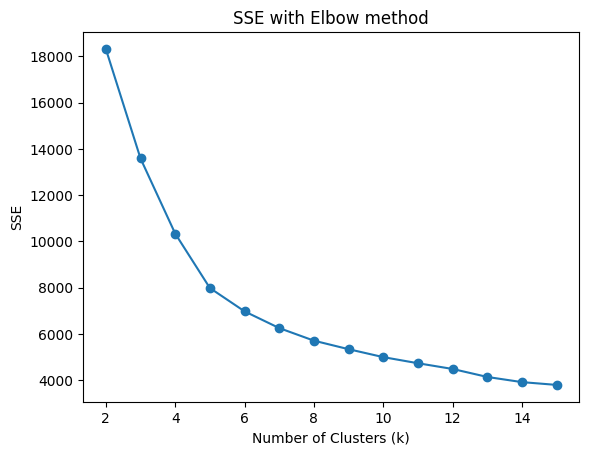

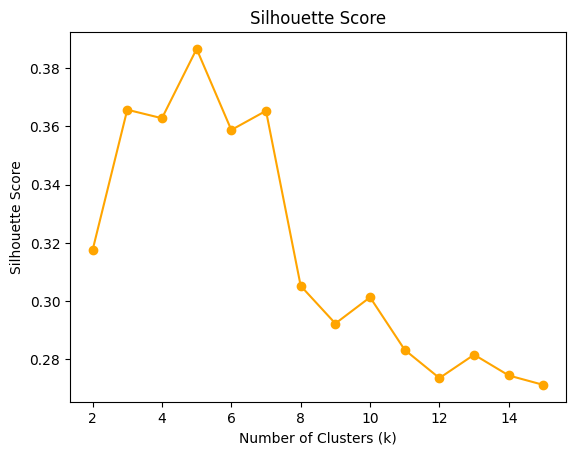

In [80]:
k_means_evaluation_plotting(results)

## Compute Kmeans algorithm with best K found
Analyzing the Elbow Method of SSE and the Silhouette Score, the values approximately align at k = 5, where the Silhouette Score is the highest.

In [81]:
kmeans_data = kmeans_run(data=pca_std_numeric_races, best_k=5, scaler=standardizer['scaler'])
best_kmeans = kmeans_data['best_kmeans']
centroids = kmeans_data['centroids']


Best k: 5
k: 5, Number of iterations: 11
Centroids
[[ 1.00260300e+02  9.05266710e-03  2.68261890e+02  1.61291908e+03
   1.71398935e+05]
 [ 6.73575136e+01  1.07236928e-02  1.97118153e+02  8.02556597e+02
   1.78092608e+05]
 [ 7.42730743e+01  2.44452501e-02  1.11134973e+03  1.15204435e+03
   1.78793438e+05]
 [ 2.59861713e+02  1.33719013e-02  2.34730001e+02  9.37890506e+02
   2.54417316e+05]
 [ 5.40201624e+01  1.55926291e-02 -1.44412953e+01  8.75812605e+02
   4.83712409e+04]]


In [82]:
# count points for each cluster
cluster_counts = pd.Series(best_kmeans.labels_).value_counts().sort_index()

print("Number of points for each cluster")
print(cluster_counts)

Number of points for each cluster
0     688
1    2446
2     861
3     508
4     747
Name: count, dtype: int64


In [83]:
numeric_races_df = numeric_races_df.copy() 
# Add Cluster as a column to the dataset
numeric_races_df['Cluster'] = best_kmeans.labels_

# Compute statistics for each feature grouped by cluster
detailed_cluster_stats = numeric_races_df.groupby('Cluster').agg(['mean', 'median', 'min', 'max'])

detailed_cluster_stats.columns = ['_'.join(col) for col in detailed_cluster_stats.columns]

display(detailed_cluster_stats)


,points_mean,points_median,points_min,points_max,climb/length_mean,climb/length_median,climb/length_min,climb/length_max,median_delta_mean,median_delta_median,median_delta_min,median_delta_max,startlist_quality_mean,startlist_quality_median,startlist_quality_min,startlist_quality_max,length_mean,length_median,length_min,length_max
Cluster,,,,,,,,,,,,,,,,,,,,
0,97.325581,100.0,50,100,0.010005,0.009577,0.000069,0.028955,202.993459,50.5,0.0,1445.0,1627.609012,1646.0,1177,2047,177139.098837,190000.0,4600,299000
1,64.598528,50.0,18,150,0.011618,0.011505,0.000670,0.029484,135.432747,23.0,0.0,1336.0,816.876942,835.0,115,1269,183625.584628,182000.0,101000,292000
2,77.421603,80.0,30,125,0.023436,0.022045,0.006052,0.063458,1180.459930,1130.0,33.5,3018.0,1135.960511,1023.0,327,2047,172391.916376,175000.0,6800,269000
3,263.139764,275.0,225,350,0.012310,0.013256,0.001265,0.021826,308.020669,270.0,0.0,1714.0,920.875984,874.0,241,1794,247843.385827,254900.0,175000,299000
4,59.809906,50.0,18,100,0.013670,0.012531,0.000191,0.062373,116.272423,57.0,0.0,730.0,844.144578,830.0,156,1959,36476.894244,23500.0,1000,144000


## Distribution of points for each feature across clusters

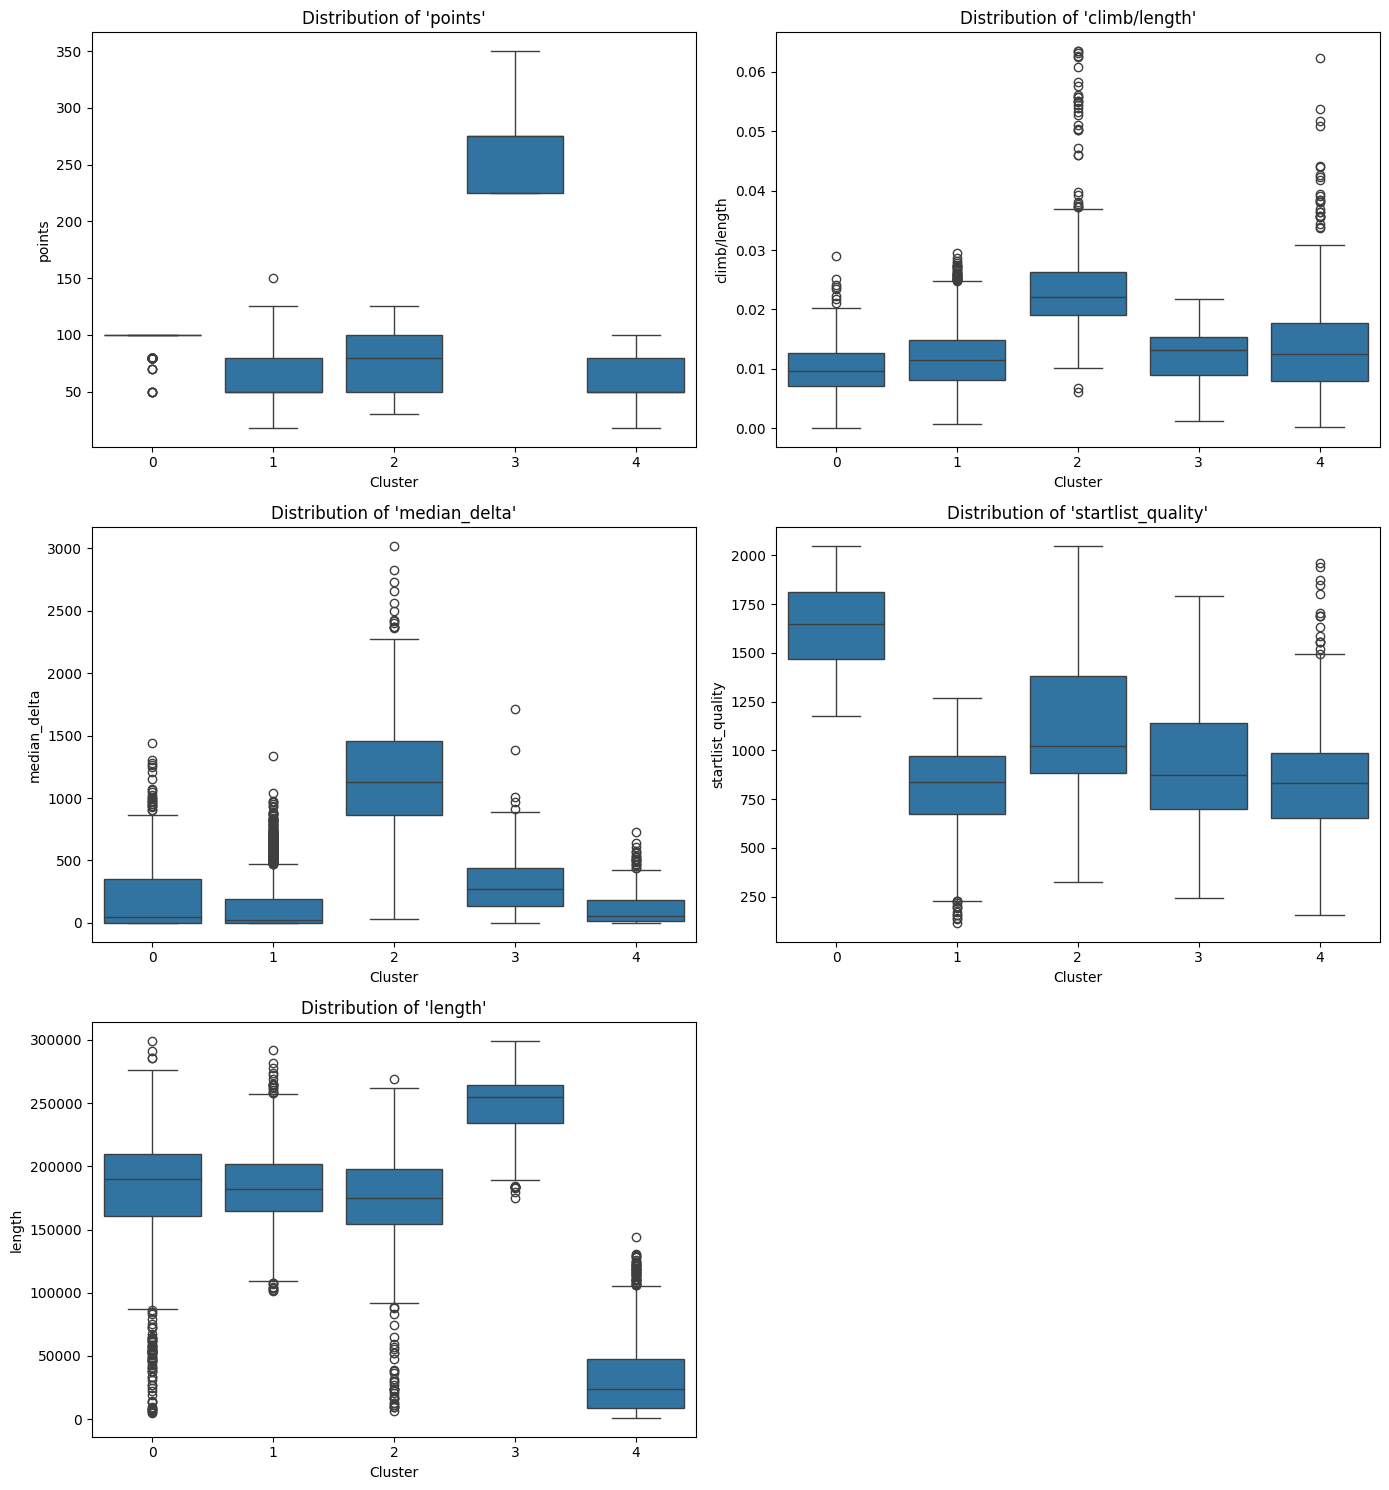

In [84]:
clusters_box_plot(numeric_races_df)

### Box-plots analysis

By analying the box-plots above, we can try to analyze the 5 clusters by considering points distribution for each feature:
- **Cluster 0** (688 points): 
  
  - **_points_**: median value is 100, and IQR is extremely narrow, the narrowest. There are low-end outliers, with the minimum around 50.
  
  - **_climb/lenght_**: the IQR is slightly narrow, with a median around ~0.01, the lowest compared to the other clusters. Several outliers are found in the upper part, up to approximately ~0.025.

  - **_median\_delta_**: IQR is moderate, ranging from just above 0 up to around ~400. There are many high-end outliers, the highest around ~1500. The median is approximately ~50.

  - **_startlist\_quality_**: the median of startlist_quality is the highest, meaning this is the cluster with races that attract the most competitive cyclists. IQR ranges from ~1500 to ~1800. There are no outliers.

  - **_length_**: the IQR is the widest, ranging from ~160000 to ~210000. The median races length is around ~190000. There are many low-end and some high-end outliers, with the minimum ~4000 and the maximum around ~299000.

- **Cluster 1** (2446 points): 
  
  - **_points_**: median here is 50 and IQR ranges from ~50 to ~80. There are one or few high-end outliers, just above 150.
  
  - **_climb/lenght_**: median is slightly higher compared to the Cluster 0, with a median around ~0.011 and a just wider IQR. We can find several outliers in the upper part, up to 0.03.  

  - **_median\_delta_**: IQR is among the narrowest, and the median is the lowest, just above 0. There are many high-end outliers. 
  
  - **_startlist\_quality_**: median is around ~850 and IQR ranges from ~700 to ~1000. There are several low-end outliers, with the minimum aroung ~100. This is the only cluster with low-end outliers here.

  - **_length_**: IQR is among the narrowest, and the median races length is just below the one in CLuster 0, around ~180000. There are both low and high end outliers.
  
- **Cluster 2** (861 points):

  - **_points_**: IQR is among the widest, ranging from ~50 to ~100. The median value of points is around ~80. There are no outliers.
  
  - **_climb/lenght_**: this ratio here is the highest, probably indicating races with the greater number of climbs per length. Median is around ~0.022. There are a lot of outliers, especially in the upper part, reaching up above 0.06.

  - **_median\_delta_**: the median delta is the highest compared to the other clusters. Also the IQR is the widest, ranging from just below 1000 up to ~1500. The median value is around ~1200. There are several high-end outliers up to ~3000.
  
  - **_startlist\_quality_**: IQR is the widest, ranging from ~850 to ~1350. The median is just above 1000. There are no outliers.

  - **_length_**: the median here is quite similar to the ones in the previous clusters, but slightly lower. The IQR ranges from around ~155000 to ~200000. There are many low-end outliers and few in the upper part.
  
- **Cluster 3** (508 points):
  
  - **_points_**: here there are races that give the most points, with a median around ~275. IQR ranges from ~225 to ~275. There are no outliers.
  
  - **_climb/lenght_**: this ratio here is the second highest, with a median around ~0.013. There are no outliers.

  - **_median\_delta_**: median is approximately ~250 and there are several high-end outliers, with the highest around ~1700.
  
  - **_startlist\_quality_**: IQR is enough wide, ranging from ~750 to ~1200, and a median of ~850. There are no outliers. 

  - **_length_**: this cluster contains the longest races, with a median around ~250000. There are some low-end outliers.
  
- **Cluster 4** (747 points):
  
  - **_points_**: the number of points here is the lowest, with a median just above 50. IQR is quite similar to that of Cluster 1. There are no outliers.
  
  - **_climb/lenght_**: the IQR is the widest, and the median is around ~0.012. There are no outliers.

  - **_median\_delta_**: the IQR is among the narrowest with a median around ~50. There are several high-end outliers, up to ~800.
  
  - **_startlist\_quality_**: the median is similar to that of Cluster 1, around ~850, but the IQR is slightly wider. This is the only cluster containing high-end outliers for this feature, with the maximum up to 2000.

  - **_length_**: here there are the shorter races, with a median length around ~23000. There are several high-end outliers, up to ~150000.
  

Based on the analysis provided, here’s what we can infer about the clusters:
#### Cluster 0
Cluster 0 may is characterized by races among that give the most _points__, with a median of 100. The IQR is very narrow, showing little variability in the points distribution, although there are low-end outliers with points dropping to around 50. These races have the lowest _climb/length_ ratio, with a median of 0.01, indicating easier climbs. A few outliers extend up to 0.025, suggesting some races with greater climbing challenges.

Performance variability, as indicated by _median\_delta_, is moderate. High-end outliers, however, reach up to approximately 1500, reflecting a subset of cyclists with extreme inconsistency in their performance. This cluster has the highest startlist_quality and no outliers, suggesting consistently competitive races. The races in this cluster are generally long, with a median length of 190,000 meters, though the range is broad. Outliers at both extremes indicate a mix of shorter and longer races.

#### Cluster 1
Cluster 1 is characterized by races among that give fewer _points__, with a median of 50 and an IQR ranging from 50 to 80. The _climb/length_ ratio has a median of 0.011, slightly higher than in Cluster 0, with a moderately narrow IQR. Outliers in the upper range reach up to 0.03, indicating a small number of more challenging races.

Performance consistency, as measured by _median\_delta_, is relatively stable for most races, with a narrow IQR. However, a significant number of high-end outliers suggest different races with extreme inconsistency. The _startlist\_quality_ in this cluster is moderate, with a median of approximately 850. Notably, this cluster includes low-end outliers with startlist quality dropping to around 100, reflecting a mix of competitive and less competitive events. Race lengths are typically around 180,000 meters, with a narrow IQR.

#### Cluster 2
Cluster 2 includes moderate races in terms of _points_ awarded, with a median of 80 and a relatively wide IQR from 50 to 100. The _climb/length_ ratio is the highest among all clusters, with a median of 0.022, reflecting the challenging nature of these races. Upper outliers extend beyond 0.06, indicating some extreme climbing conditions.

The _median\_delta_ feature shows the highest performance variability. There are also several high-end outliers, highlighting races with extreme inconsistency. _Startlist\_quality_ in this cluster is moderately high, with a median of just above 1000 and the widest IQR. Race lengths are moderate, with a median of 178,000 meters and an IQR from 155,000 to 200,000 meters. Low-end outliers reflect shorter races, while a few high-end outliers suggest longer ones.

#### Cluster 3
Cluster 3 represents the races that give the most _points_, which a median of 275. _The climb/length_ ratio is moderate, with a median of 0.013 and no outliers, indicating a consistent difficulty level, considering the climbs.

_Median\_delta_ values are relatively stable. High-end outliers reach up to 1700, showing occasional variability in cyclist performance. These races are the longest in terms of distance, with a median length of 250,000 meters and a narrow IQR. A few low-end outliers indicate the presence of shorter races.

#### Cluster 4
Cluster 4 includes the races that give the lowest number of _points_, with a median of 50 and no outliers. The _climb/length_ ratio shows the widest IQR, with a median of 0.012, reflecting a mix of easier and harder climbs. A several number of outliers extend beyond the upper range.

_Median\_delta_ values indicate moderate variability, with an IQR from 0 to 150 and a median around 50. Several high-end outliers reach up to 800, indicating occasional inconsistency in performance. Startlist_quality is moderate and, unlike other clusters, this one contains high-end outliers in startlist_quality. Race lengths are the shortest, with a median of 23,000 meters. Many high-end outliers extend up to 150,000 meters, indicating some diversity in race types.


Let's resume:

Clusters 0 and 3 represent high-performing races. Cluster 0 stands out as the most attractive group, with consistently high points and strong competition, while Cluster 3 features the longest races that also award the highest points. Cluster 2 is distinctive for its challenging climbs and high variability in performance. In contrast, Clusters 1 and 4 represent lower-performing races, with Cluster 4 being notable for its shorter race lengths and occasional competitive outliers.

## Clusters visualization with feature distributions and centroids 

/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_3496/1658901490.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


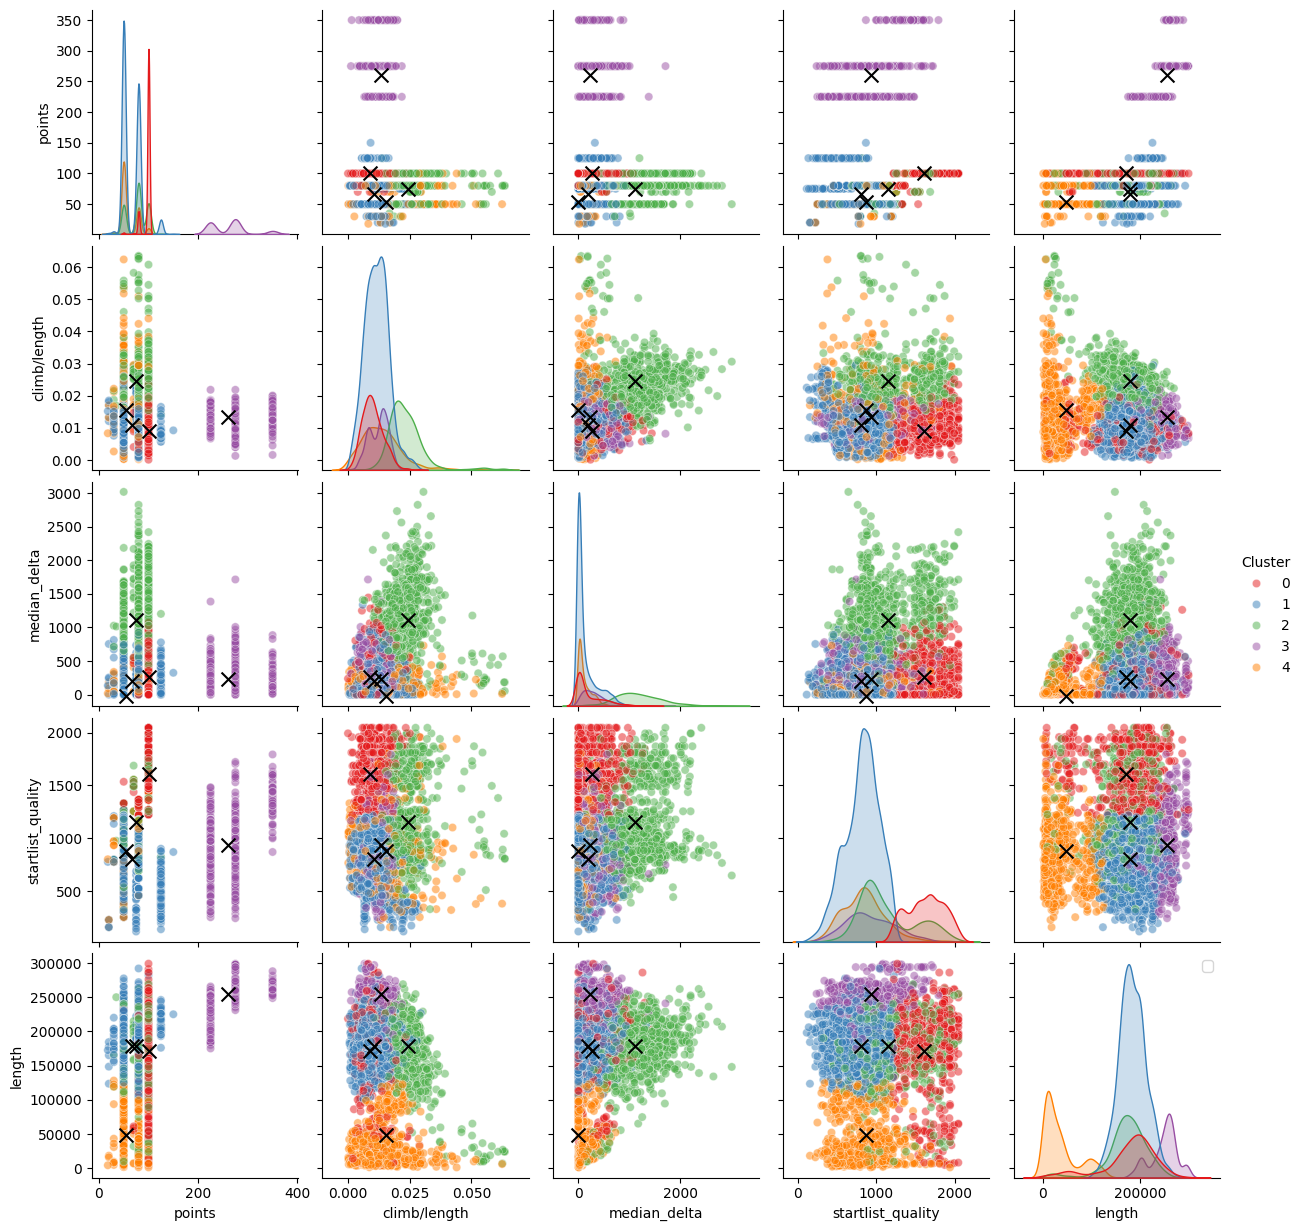

In [85]:
clusters_pairplot(numeric_races_df, centroids)

### Pairplot analysis

By analyzing the paiplot above, we can try to analyze the 6 clusters and try to catch any relationships and patterns between the characteristics of the clusters that we were unable to catch with the box plots

- **Cluster 0**:
  - **_points_** vs **_startlist\_quality_**_ as the number of point awarded increses, also the quality of the startlist increases. It may suggests that in this cluster, races that give more points tend to attract stronger cyclists.

- **Cluster 1**:
  - **_points_** vs **_startlist\_quality_**: it seems there is a light relationship. As the number of points awarded increases, the startlist quality decreases.
  
  - **_startlist\_quality** vs **_climb\_length_**: there seems to be a weak correlation: as the climb/length ration increses, the startlist quality decreases. It could mean that in this cluster more difficult races, therefore with an higher percentage of climbs per length, tend do be less attractive for stronger cyclists.
  
- **Cluster 2**:
  - **_median\_delta_** vs **_length_**: longer races tend to have higher median delta values
  
  - **_climb\_length_** vs **_length_**: seems to be a negative correlation. As the races length increases, the ratio climb/length tends to decrease.

  - **_median\_delta_** vs **climb/length**: here, races with more climbs per length tend to have lower median_delta values, reflecting the fact that hills influence arrival times.
  

- **Cluster 3**:
  - **_points_** vs **_startlist\_quality_**: also in this cluster, there is a relation. As the number of point awarded increses, also the quality of the startlist increases. It may suggests that in this cluster as the cluster 0, races that give more points tend to attract stronger cyclists.
  
  - **_length_** vs **_startlist\_quality_**: it seems that races with a better startlist quality tend to be longer

  - **_length_** vs **_median\_delta_**: there seems to be a correlation, although very weak. As the length increases, the median delta tends to decrease.
  
- **Cluster 4**: 
  - **_climb\_length_** vs **_length_**: seems to be a negative correlation. As the races length increases, the ratio climb/length tends to decrease.
	

 

### Parallel coordinates plot

In [86]:
columns = numeric_races_df.drop('Cluster',axis=1).columns

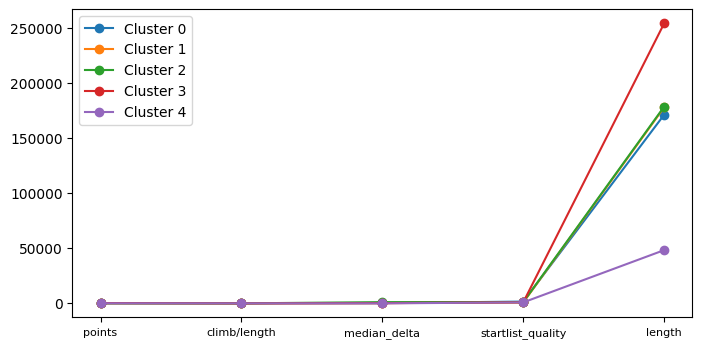

In [87]:
plt.figure(figsize=(8, 4))
for i in range(0, len(centroids)):
    plt.plot(centroids[i], marker='o', label='Cluster %s' % i)
plt.tick_params(axis='both', which='major', labelsize=10)
plt.xticks(range(0, len(columns)), columns, fontsize=8)
plt.legend(fontsize=10)
plt.show()

Plotting with normalized centroids

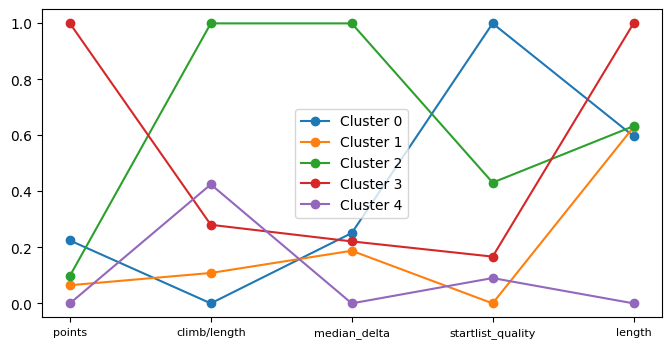

In [88]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
centroids_normalized = scaler.fit_transform(centroids)

plt.figure(figsize=(8, 4))
for i in range(0, len(centroids_normalized)):
    plt.plot(centroids_normalized[i], marker='o', label='Cluster %s' % i)

plt.tick_params(axis='both', which='major', labelsize=10)
plt.xticks(range(0, len(columns)), columns, fontsize=8)
plt.legend(fontsize=10)
plt.show()

### Spider plot

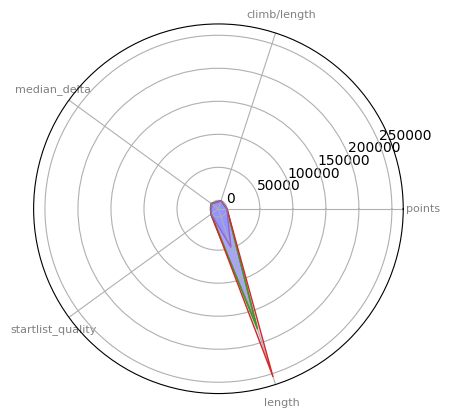

In [89]:
from math import pi
 
# number of variable
N = len(columns)
# What will be the angle of each axis in the plot? (we divide the plot / number of variable)
for i in range(0, len(centroids)):
    angles = [n / float(N) * 2 * pi for n in range(N)]
    values = centroids[i].tolist()
    values += values[:1]
    angles += angles[:1]
# Initialise the spider plot
    ax = plt.subplot(polar=True)
# Draw one axe per variable + add labels labels yet
    plt.xticks(angles[:-1], columns, color='grey', size=8) 
# Plot data
    ax.plot(angles, values, linewidth=1, linestyle='solid')
 # Fill area
    ax.fill(angles, values, 'b', alpha=0.1)

Spider plot with centroids normalized

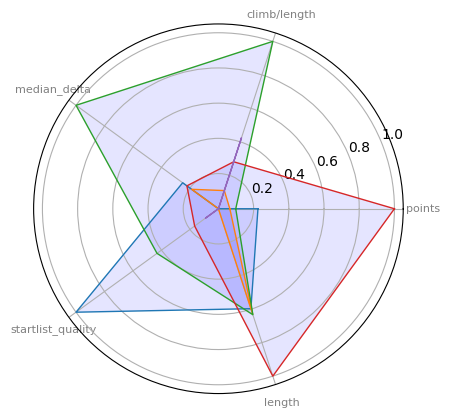

In [90]:
# number of variable
N = len(columns)
# What will be the angle of each axis in the plot? (we divide the plot / number of variable)
for i in range(0, len(centroids_normalized)):
    angles = [n / float(N) * 2 * pi for n in range(N)]
    values = centroids_normalized[i].tolist()
    values += values[:1]
    angles += angles[:1]
# Initialise the spider plot
    ax = plt.subplot(polar=True)
# Draw one axe per variable + add labels labels yet
    plt.xticks(angles[:-1], columns, color='grey', size=8) 
# Plot data
    ax.plot(angles, values, linewidth=1, linestyle='solid')
 # Fill area
    ax.fill(angles, values, 'b', alpha=0.1)

## Similarity Matrix for Clusters Validation

In [92]:
num_components = pca_std_numeric_cyclists.shape[1]
column_names = [f'PC{i+1}' for i in range(num_components)]

# Convert pca ndarray into a dataframe
pca_df_races = pd.DataFrame(pca_std_numeric_races, columns=column_names)

print(pca_df_races.head())

        PC1       PC2       PC3       PC4
0 -0.554582  0.791796  0.921211  0.006304
1  3.060222 -1.959799 -1.472823 -0.714172
2 -0.317300  0.638804  2.187790  0.194220
3 -1.947581 -1.171056  0.599172  0.820238
4  2.532325 -0.652669  0.715125 -0.589366


Pearson correlation between the proximity matrix and the ideal similarity matrix: 0.6233


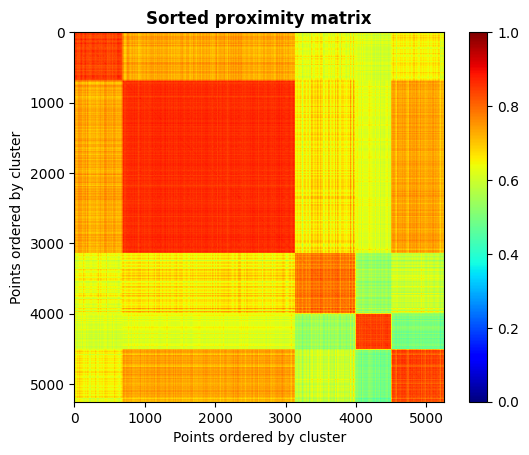

In [93]:
compute_similarity_matrix(pca_df_races, best_kmeans.labels_)


In [ ]:
for i in numeric_races_df['Cluster'].unique():
    if i != -1:
        # std_dev for each numeric column
        std_values = numeric_races_df[numeric_races_df['Cluster'] == i].std(numeric_only=True)
        mean_std = std_values.mean()
        print(f"Cluster {i}: Average standard deviation = {mean_std}")